# Regularization

When we explored Multiple Linear Regression, we tried to select features by inspecting correlations between a feature and the target as well as between features. But how did we know if we were using the right features and the right number of features? We didn't.

*Regularization* is a tool for automatically emphasizing the features that are informative as you fit the model. Recall, in fitting linear regression models, we are minimizing the mean-squared error between our predictions and the true values. The cost function has the form:

$$
J(\Theta) = \frac{1}{m}\sum_{i=0}^m(y_i - \hat{y}_i)^2
$$

Regularization adds a term to the cost function that penalizes large feature weights ($\theta_i$). Three common regularization algorithms for linear regression are:

 - [Ridge regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html):

 $$
J_{\text{ridge}}(\Theta) = \underbrace{\frac{1}{n}\sum_{i=0}^n(y_i - \hat{y}_i)^2}_{MSE(\Theta)} + \frac{\alpha}{n} \cdot \underbrace{\sum_{i=0}^p \theta_i^2}_{\text{L2 norm}}
$$

 - [Lasso regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) (Least Absolute Shrinkage and Selection Operator):

 $$
J_{\text{lasso}}(\Theta) = \underbrace{\frac{1}{n}\sum_{i=0}^n(y_i - \hat{y}_i)^2}_{MSE(\Theta)} + 2\alpha \cdot \underbrace{\sum_{i=0}^p |\theta_i|}_{\text{L1 norm}}
$$

- [Elastic Net](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) (combines Ridge and Lasso)

 $$
J_{\text{elastic net}}(\Theta) = \underbrace{\frac{1}{n}\sum_{i=0}^n(y_i - \hat{y}_i)^2}_{MSE(\Theta)} + r\cdot\underbrace{\frac{\alpha}{n} \cdot \frac{1}{2}\sum_{i=0}^p \theta_i^2}_{\text{Ridge}} + (1-r)\underbrace{\cdot2\alpha \cdot \sum_{i=0}^p |\theta_i|}_{\text{Lasso}}
$$

Where 
 - $\alpha$ is a hyper-parameter that balances how much you want to balance model simplification and model fit.
 - L2 norm is the sum of squared values of weights
 - L1 norm is the sum of the absolute values of weights
 - $r$ is a hyper-parameter in the range (0,1) that balances the amount of L2 (Ridge) and L1 (Lasso) penalty

That Ridge uses the L2-norm and Lasso uses the L1-norm can be reduced to the following observation:
 - Ridge regression will make some weights small, but not zero. This is useful if you believe many of the features contribute to the model.
 - Lasso regression will drive some weights to zero. This is useful if you believe only a few weights contribute.

 However, we generally don't know in advance how our features will contribute to the model, so best to try both and compare.


 ### Why/when to use regularization?

 - *High-dimensional data.* When number of features (p) is larger than the number of samples (n), linear regression (Ordinary Least Squares) fails.
 - *Colinear features.* Linear regression yields unstable coefficient estimates because multiple best-fit solutions exist.
 - *Model over-fitting.* Even when p<n, you may have too many parameters. That is, you're using a model more complex than the data requires. (More about that next class!)
 - *Feature selection.* You want to build a model with fewer features.

### Example: Baseball Salary Prediction (1986)

In [57]:
import pandas as pd
pd.set_option('display.precision', 2)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
data_df = pd.read_csv('https://raw.githubusercontent.com/acakin/hitters/refs/heads/master/hitters.csv')      
data_df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [59]:
data_df.dropna(inplace=True)

In [60]:
cat_features = ['League', 'Division', 'NewLeague']
league_df = pd.get_dummies(data_df[cat_features], dtype=int)
league_df

,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
1,0,1,0,1,0,1
2,1,0,0,1,1,0
3,0,1,1,0,0,1
4,0,1,1,0,0,1
5,1,0,0,1,1,0
...,...,...,...,...,...,...
317,0,1,1,0,0,1
318,1,0,1,0,1,0
319,1,0,0,1,1,0
320,1,0,1,0,1,0


In [61]:
hitters_df = data_df.drop(columns = cat_features).join(league_df)
hitters_df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,0,1,0,1,0,1
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,1,0,0,1,1,0
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,0,1,1,0,0,1
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,0,1,1,0,0,1
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,325,9,3,700.0,0,1,1,0,0,1
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,313,381,20,875.0,1,0,1,0,1,0
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,37,113,7,385.0,1,0,0,1,1,0
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,1314,131,12,960.0,1,0,1,0,1,0


<Axes: >

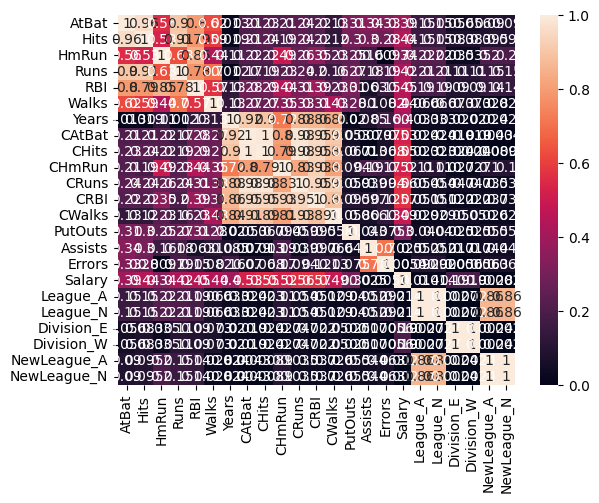

In [62]:
hitters_corr = hitters_df.corr()
sns.heatmap(np.abs(hitters_corr), vmin = 0, vmax = 1, annot = True)

In [63]:
target = ['Salary']

y = hitters_df[target]
X = hitters_df.drop(columns = target)

features = list(X.columns)
features.append('intercept')


In [64]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import root_mean_squared_error, r2_score

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

sc = StandardScaler()

Z_train = sc.fit_transform(X_train)
Z_test = sc.transform(X_test) 

In [66]:
linreg = LinearRegression()
linreg.fit(Z_train, y_train)

y_linreg_train = linreg.predict(Z_train)
y_linreg_test = linreg.predict(Z_test)

R2_linreg_train = r2_score(y_train, y_linreg_train)
R2_linreg_test = r2_score(y_test, y_linreg_test)

In [67]:
alpha = np.logspace(-2, 2, 9)
alpha

lasso_metrics = {}
ridge_metrics = {}
elnet_metrics = {}

lasso_coeffs = {}
lasso_coeffs['feature'] = features

ridge_coeffs = {}
ridge_coeffs['feature'] = features

elnet_coeffs = {}
elnet_coeffs['feature'] = features

for a in alpha:
    
    print(f'Computing for alpha = {a:.3f}')
    lasso = Lasso(alpha = a)
    lasso.fit(Z_train, y_train)
    
    lasso_coeffs[a] = np.append(lasso.coef_, lasso.intercept_)
    
    y_lasso_train = lasso.predict(Z_train)
    y_lasso_test = lasso.predict(Z_test)
    
    lasso_metrics[a] = {'R2_train': r2_score(y_train, y_lasso_train),
                        'R2_test': r2_score(y_test, y_lasso_test),
                        'RMSE_train': root_mean_squared_error(y_train, y_lasso_train), 
                        'RMSE_test': root_mean_squared_error(y_test, y_lasso_test)}
    
    ridge = Ridge(alpha = a)
    ridge.fit(Z_train, y_train)
        
    ridge_coeffs[a] = np.append(ridge.coef_, ridge.intercept_)
        
    y_ridge_train = ridge.predict(Z_train)
    y_ridge_test = ridge.predict(Z_test)
        
    ridge_metrics[a] = {'R2_train': r2_score(y_train, y_ridge_train),
                        'R2_test': r2_score(y_test, y_ridge_test),
                        'RMSE_train': root_mean_squared_error(y_train, y_ridge_train), 
                        'RMSE_test': root_mean_squared_error(y_test, y_ridge_test)}
    
    elnet = ElasticNet(alpha = a, l1_ratio = 0.5)
    elnet.fit(Z_train, y_train)
    
    elnet_coeffs[a] = np.append(elnet.coef_, elnet.intercept_)
    
    y_elnet_train = elnet.predict(Z_train)
    y_elnet_test = elnet.predict(Z_test)
    
    elnet_metrics[a] = {'R2_train': r2_score(y_train, y_elnet_train),
                        'R2_test': r2_score(y_test, y_elnet_test),
                        'RMSE_train': root_mean_squared_error(y_train, y_elnet_train), 
                        'RMSE_test': root_mean_squared_error(y_test, y_elnet_test)}
    
    
    

Computing for alpha = 0.010
Computing for alpha = 0.032
Computing for alpha = 0.100
Computing for alpha = 0.316
Computing for alpha = 1.000
Computing for alpha = 3.162
Computing for alpha = 10.000
Computing for alpha = 31.623
Computing for alpha = 100.000


/Users/eatai/.pyenv/versions/datascience/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.040e+06, tolerance: 3.912e+03
  model = cd_fast.enet_coordinate_descent(
/Users/eatai/.pyenv/versions/datascience/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.287e+06, tolerance: 3.912e+03
  model = cd_fast.enet_coordinate_descent(
/Users/eatai/.pyenv/versions/datascience/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the

In [68]:
lasso_df = pd.DataFrame(lasso_coeffs)
lasso_df.sort_values(by = 100.0, ascending = False)

,feature,0.01,0.03,0.1,0.32,1.0,3.16,10.0,31.62,100.0
22,intercept,5.11e+02,5.11e+02,5.11e+02,5.11e+02,5.11e+02,5.11e+02,5.11e+02,511.39,511.39
10,CRuns,5.80e+02,5.78e+02,5.71e+02,5.48e+02,4.72e+02,3.24e+02,1.98e+02,183.75,129.90
1,Hits,2.43e+02,2.43e+02,2.42e+02,2.39e+02,2.27e+02,1.76e+02,6.81e+01,53.93,27.61
5,Walks,1.14e+02,1.14e+02,1.13e+02,1.11e+02,1.03e+02,7.95e+01,3.89e+01,36.71,24.49
4,RBI,2.33e+01,2.36e+01,2.45e+01,2.76e+01,3.77e+01,3.86e+01,2.33e+01,23.08,23.41
13,PutOuts,9.80e+01,9.80e+01,9.81e+01,9.82e+01,9.85e+01,9.60e+01,8.95e+01,73.48,20.19
14,Assists,4.73e+01,4.70e+01,4.62e+01,4.38e+01,3.65e+01,1.34e+01,-0.00e+00,-0.00,0.00
21,NewLeague_N,-0.00e+00,-0.00e+00,-0.00e+00,-0.00e+00,-0.00e+00,-0.00e+00,0.00e+00,0.00,0.00
20,NewLeague_A,3.91e+01,3.89e+01,3.82e+01,3.60e+01,2.94e+01,1.07e+01,-0.00e+00,-0.00,-0.00
19,Division_W,-8.19e-12,-6.00e-12,-5.95e-12,-7.25e-12,-5.28e-12,-1.41e-12,-2.43e-13,-0.00,-0.00


In [70]:
ridge_df = pd.DataFrame(ridge_coeffs)
ridge_df.sort_values(by = 100.0, ascending = False)

,feature,0.01,0.03,0.1,0.32,1.0,3.16,10.0,31.62,100.0
22,intercept,511.39,511.39,511.39,511.39,511.39,511.39,511.39,511.39,511.39
13,PutOuts,98.03,98.00,97.89,97.54,96.56,94.50,90.46,81.22,62.92
10,CRuns,593.50,588.11,570.76,519.75,408.84,261.61,144.69,78.74,47.19
8,CHits,220.74,215.57,203.41,183.57,161.55,136.40,102.52,67.55,43.81
1,Hits,250.27,250.32,249.83,245.21,224.35,171.50,103.94,60.11,39.59
5,Walks,115.32,115.27,114.99,113.48,107.35,91.26,67.48,48.08,37.34
11,CRBI,157.53,155.67,149.31,130.33,96.13,69.43,56.32,44.06,34.31
3,Runs,-48.03,-47.18,-44.39,-35.99,-17.02,8.73,26.06,30.20,28.68
7,CAtBat,-529.24,-517.27,-483.69,-403.71,-262.93,-109.57,-13.96,20.45,26.64
4,RBI,21.47,21.72,22.56,24.94,29.20,32.36,31.29,26.90,24.41


In [71]:
elnet_df = pd.DataFrame(elnet_coeffs)
elnet_df.sort_values(by = 100.0, ascending = False)

,feature,0.01,0.03,0.1,0.32,1.0,3.16,10.0,31.62,100.0
22,intercept,511.39,511.39,511.39,511.39,511.39,511.39,511.39,511.39,511.39
10,CRuns,402.52,255.13,140.19,76.42,46.32,31.57,20.64,10.36,3.59
8,CHits,160.45,134.78,100.35,65.87,43.04,29.96,19.71,9.90,3.41
11,CRBI,94.34,68.17,55.02,43.31,33.96,27.02,18.95,9.74,3.38
7,CAtBat,-255.52,-103.17,-10.45,20.58,26.62,24.20,17.69,9.20,3.18
12,CWalks,-143.82,-101.06,-47.12,-3.58,16.47,21.07,16.59,8.75,3.01
9,CHmRun,-35.45,-16.74,-5.17,6.75,16.54,19.70,15.99,8.59,2.96
5,Walks,106.83,90.22,66.25,47.11,36.93,28.45,18.41,8.80,2.87
4,RBI,29.43,32.44,31.10,26.63,24.35,22.57,16.68,8.48,2.83
1,Hits,222.67,168.42,101.11,58.44,38.91,27.54,17.52,8.35,2.68
